# 🧴 Análisis Exploratorio de Datos (EDA) - Base de Cosmética

Este notebook tiene como objetivo analizar la base de datos `db_cosmetica.db` para entender la calidad y distribución de los datos que alimentan nuestro sistema RAG.

**Objetivos:**
1. **Inspección Inicial:** Cargar los datos y revisar su estructura, tipos y valores nulos.
2. **Análisis de Textos:** Evaluar la longitud y calidad de las descripciones e ingredientes.
3. **Análisis de Ingredientes:** Identificar los ingredientes más comunes para mejorar nuestro filtro de intención.
4. **Verificación de Embeddings:** Asegurar que los vectores de embedding son consistentes.
5. **Conclusiones:** Extraer insights accionables para mejorar el asistente Kim.

In [16]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
import numpy as np

# Configuración de estilo para las visualizaciones
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Nombre de la base de datos
DB_NAME = 'db_cosmetica.db'

## 1. Carga e Inspección Inicial de Datos

In [17]:
try:
    conn = sqlite3.connect(DB_NAME)
    df = pd.read_sql_query("SELECT * FROM productos_scraped", conn)
    conn.close()
    print(f"✅ Base de datos cargada con éxito. Total de productos: {len(df)}")
except Exception as e:
    print(f"❌ Error al leer la base de datos: {e}")

# Revisión inicial de la estructura y datos nulos
print("\n--- Información del DataFrame ---")
df.info()

print("\n--- Valores Nulos por Columna ---")
print(df.isnull().sum())

print("\n--- Primeras 5 Filas ---")
df.head()

✅ Base de datos cargada con éxito. Total de productos: 8719

--- Información del DataFrame ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8719 entries, 0 to 8718
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   nombre            8719 non-null   object 
 1   descripcion       8590 non-null   object 
 2   ingredientes      7793 non-null   object 
 3   precio            8719 non-null   float64
 4   embedding_vector  8719 non-null   object 
dtypes: float64(1), object(4)
memory usage: 340.7+ KB

--- Valores Nulos por Columna ---
nombre                0
descripcion         129
ingredientes        926
precio                0
embedding_vector      0
dtype: int64

--- Primeras 5 Filas ---


,nombre,descripcion,ingredientes,precio,embedding_vector
0,Armani Code Femme Eau de Parfum - 30ml,"Con una mezcla cautivadora y elegante, Armani ...","Dihydro Pentamethylindanone, Geranyl Acetate, ...",63.95,"[0.5190797448158264, 1.458377718925476, -3.439..."
1,HUGO BOSS HUGO Hombre Eau de Toilette 40ml,Hugo Boss HUGO Man Eau de Toilette es una frag...,"Alcohol Denat., Aqua/Water, Parfum/Fragrance, ...",33.95,"[-0.5758580565452576, 1.333964228630066, -3.32..."
2,Marc Jacobs Daisy Eau de Toilette 50ml,Marc Jacobs presenta la galardonada Daisy Eau ...,None,69.45,"[0.7425552010536194, 1.3263143301010132, -3.40..."
3,Jean Paul Gaultier Le Male Agua de Colonia 75ml,"Notas de salida: Menta, Artemisa, Cardamomo, B...",None,66.45,"[0.4495469331741333, 1.6641654968261719, -3.89..."
4,Crema reparadora calmante Elizabeth Arden Eigh...,Hay que cuidar la piel y con el producto clási...,"Petrolatum, Lanolin, Mineral Oil/Paraffinum, L...",35.95,"[0.33543118834495544, 0.9912262558937073, -2.9..."


## 2. Análisis de Longitud de Textos

La longitud de las descripciones y listas de ingredientes es crucial. Textos muy cortos pueden generar embeddings de baja calidad y limitar el contexto que le damos al LLM.

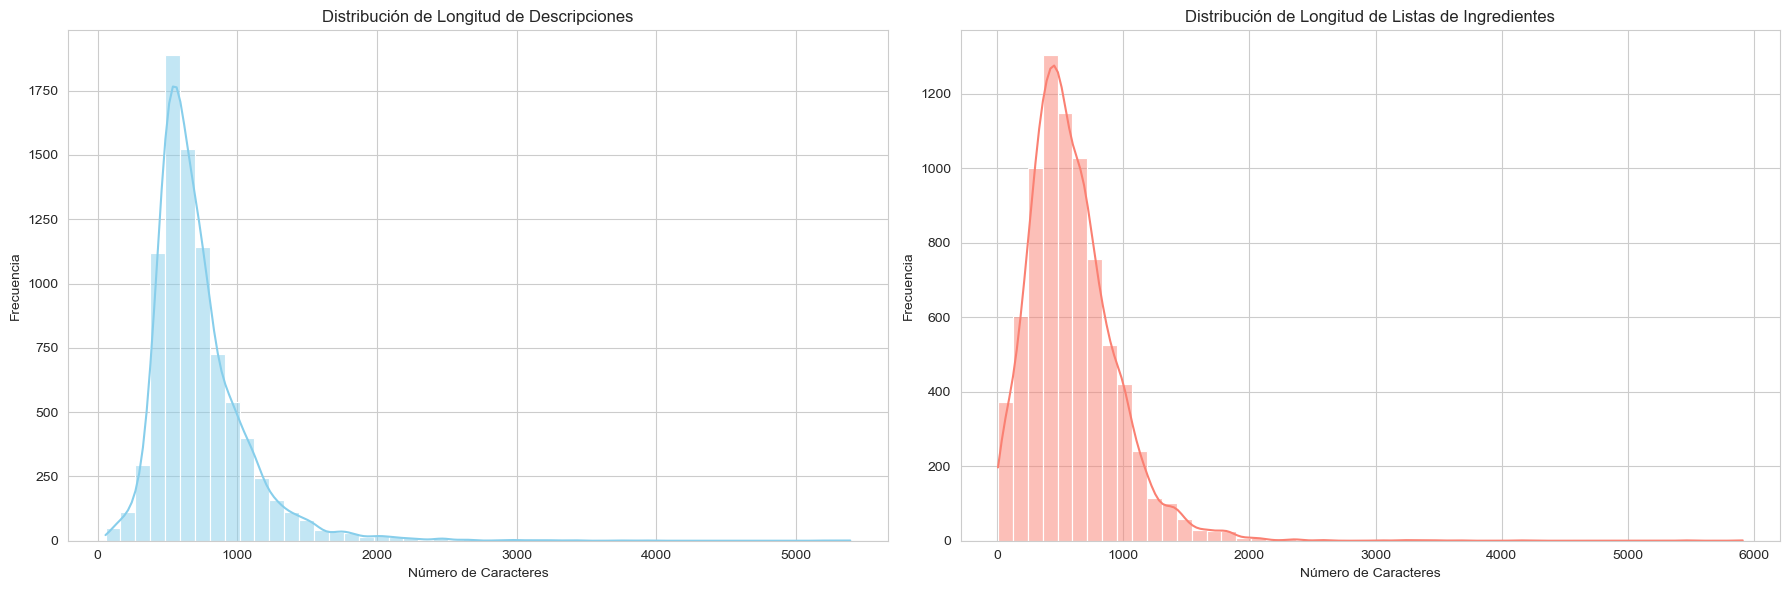

In [18]:
# Calculamos la longitud (número de caracteres) de las descripciones y los ingredientes
df['descripcion_len'] = df['descripcion'].str.len()
df['ingredientes_len'] = df['ingredientes'].str.len()

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.histplot(df['descripcion_len'], bins=50, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribución de Longitud de Descripciones')
axes[0].set_xlabel('Número de Caracteres')
axes[0].set_ylabel('Frecuencia')

sns.histplot(df['ingredientes_len'], bins=50, kde=True, ax=axes[1], color='salmon')
axes[1].set_title('Distribución de Longitud de Listas de Ingredientes')
axes[1].set_xlabel('Número de Caracteres')
axes[1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

## 3. Análisis de Ingredientes

Este es el análisis más importante para mejorar nuestro sistema. Vamos a extraer todos los ingredientes individuales para identificar los más comunes. **La lista resultante puede usarse para refinar el filtro `is_technical_query` en `app.py`.**

In [19]:
# Limpiamos y contamos la frecuencia de cada ingrediente
# Asumimos que están separados por comas
ingredient_counts = df['ingredientes'].str.split(',').explode().str.strip().str.upper().value_counts()

print("--- Top 30 Ingredientes Más Comunes ---")
top_30_ingredients = ingredient_counts.head(30)
print(top_30_ingredients)

--- Top 30 Ingredientes Más Comunes ---
ingredientes
GLYCERIN                        3945
PHENOXYETHANOL                  3281
LINALOOL                        2745
LIMONENE                        2703
CITRIC ACID                     2582
TOCOPHEROL                      2436
SODIUM BENZOATE                 1786
CITRONELLOL                     1763
BUTYLENE GLYCOL                 1692
CAPRYLYL GLYCOL                 1687
SODIUM HYDROXIDE                1672
GERANIOL                        1657
DIMETHICONE                     1636
BENZYL ALCOHOL                  1517
SODIUM HYALURONATE              1485
POTASSIUM SORBATE               1484
ETHYLHEXYLGLYCERIN              1480
TOCOPHERYL ACETATE              1327
DISODIUM EDTA                   1316
XANTHAN GUM                     1289
SILICA                          1281
CAPRYLIC/CAPRIC TRIGLYCERIDE    1277
CETEARYL ALCOHOL                1270
SODIUM CHLORIDE                 1241
CITRAL                          1225
PROPYLENE GLYCOL      

/tmp/ipykernel_43768/3103679923.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_30_ingredients.head(20).values, y=top_30_ingredients.head(20).index, palette='mako')


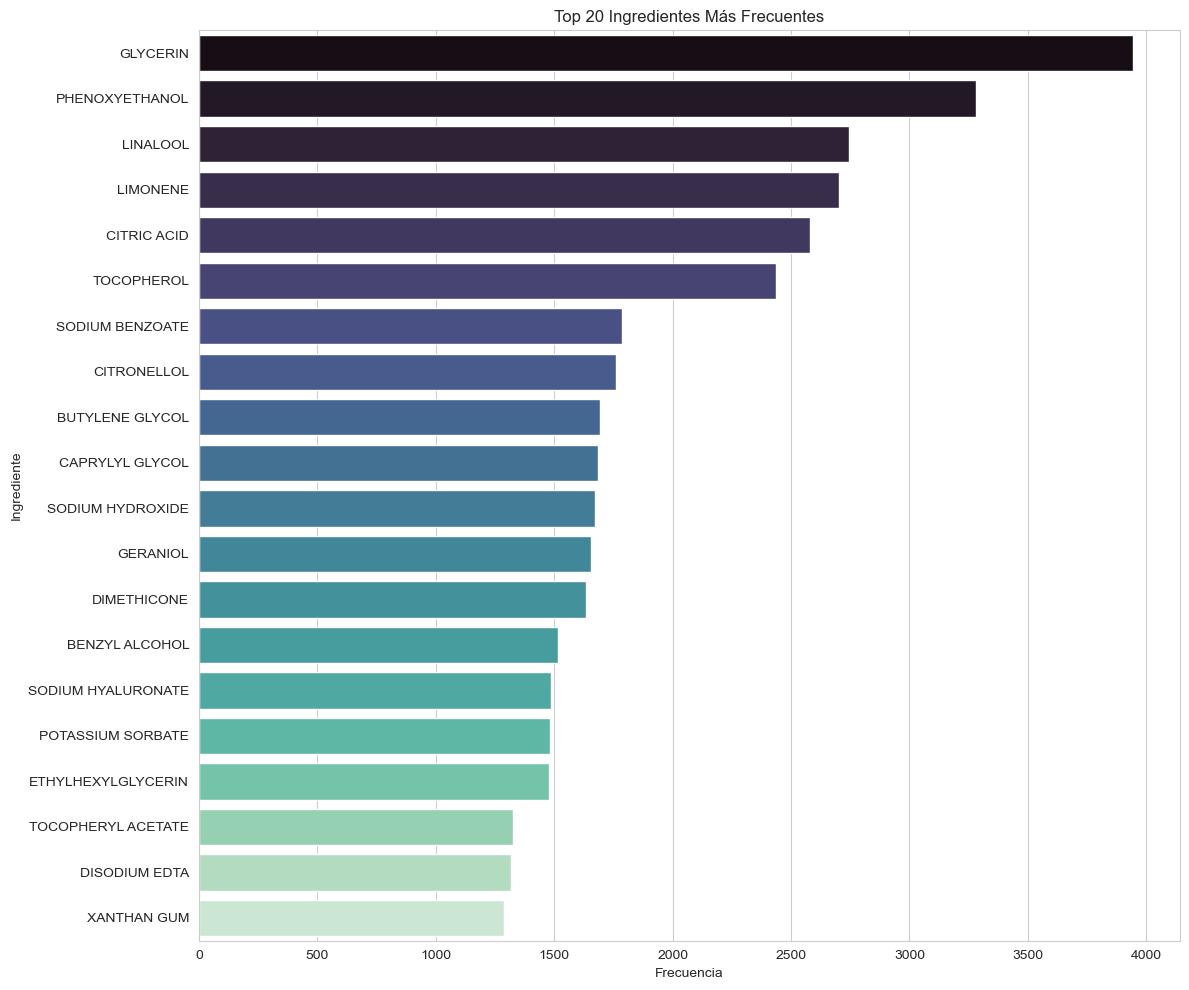

In [20]:
# Visualizamos el Top 20
plt.figure(figsize=(12, 10))
sns.barplot(x=top_30_ingredients.head(20).values, y=top_30_ingredients.head(20).index, palette='mako')
plt.title('Top 20 Ingredientes Más Frecuentes')
plt.xlabel('Frecuencia')
plt.ylabel('Ingrediente')
plt.tight_layout()
plt.show()

## 4. Verificación de Embeddings

Vamos a realizar una comprobación de sanidad para asegurarnos de que todos los vectores de embedding tienen la misma dimensión. Esto es crucial para que los cálculos de similitud de coseno funcionen correctamente.

In [21]:
def get_embedding_dim(vector_blob):
    try:
        # El vector está guardado como un string JSON
        return len(json.loads(vector_blob))
    except (json.JSONDecodeError, TypeError):
        return 0 # Devuelve 0 si hay algún error o está vacío

df['embedding_dim'] = df['embedding_vector'].apply(get_embedding_dim)

print("--- Dimensiones de los Vectores de Embedding Encontradas ---")
print(df['embedding_dim'].value_counts())

# Deberíamos ver un solo número (la dimensión de 'nomic-embed-text') con un conteo igual al total de productos.

--- Dimensiones de los Vectores de Embedding Encontradas ---
embedding_dim
768    8719
Name: count, dtype: int64


## 5. Conclusiones y Pasos a Seguir 🚀

Basado en este análisis, podemos extraer las siguientes conclusiones y acciones:

1.  **Calidad de los Datos:**
    * *Revisa la sección de valores nulos.* Si hay muchos, considera mejorar tu scraper para que sea más robusto o para que descarte productos sin información clave (como ingredientes).

2.  **Calidad del Texto:**
    * *Observa los histogramas de longitud.* Si hay muchos productos con descripciones muy cortas (ej. menos de 100 caracteres), la calidad del RAG podría verse afectada. Podrías necesitar buscar fuentes de datos con descripciones más detalladas.

3.  **¡ACCIÓN CRÍTICA! - Mejora del Filtro de Intención:**
    * **Copia la lista del Top 30 de ingredientes** que generamos en la celda 8.
    * **Ve a tu archivo `app.py` y reemplaza la lista `technical_patterns`** en la función `is_technical_query` con esta nueva lista, que está basada en TUS DATOS REALES. Esto hará que el filtro sea mucho más preciso.
    * Ejemplo de cómo debería quedar en `app.py`:
    ```python
    # app.py -> is_technical_query()
    technical_patterns = [
        'AQUA', 'GLYCERIN', 'BUTYLENE GLYCOL', 'SODIUM HYALURONATE', # ...y así sucesivamente
    ]
    ```

4.  **Consistencia de Embeddings:**
    * *Revisa la salida de la celda 11.* Si ves múltiples dimensiones o valores de 0, significa que algunos embeddings no se generaron correctamente. Deberías volver a ejecutar tu script de scraping/embedding para esos productos específicos.

## 6. Limpieza de Datos: Filtrado de Ingredientes

Hemos detectado que la columna `ingredientes` contiene datos "sucios" (instrucciones, modo de empleo) en lugar de listas INCI.

Dado que no podemos volver a ejecutar el scraper, vamos a **limpiar la base de datos directamente desde Pandas**:

1.  Crearemos una función de filtro (heurística) que decida si el texto es una lista de ingredientes o instrucciones.
2.  La aplicaremos a la columna `ingredientes`.
3.  Si el texto son instrucciones, lo convertiremos a `None` (NULL).

In [29]:
import pandas as pd
import numpy as np

def is_valid_ingredient_list(text):
    """
    Filtro heurístico para validar listas de ingredientes.
    Devuelve el texto si es válido, o None si no lo es.
    """
    # Si ya es nulo, lo dejamos nulo
    if pd.isna(text):
        return None
        
    text_upper = str(text).upper()

    # --- Filtro 1: Palabras Clave Negativas (Instrucciones) ---
    # Si contiene estas frases, es 99% seguro que son instrucciones.
    instruction_keywords = [
        'MODO DE EMPLEO', 'MODO DE USO', 'APLICAR SOBRE', 'ACLARAR CON AGUA', 
        'MASAJEAR', 'EVITAR EL CONTACTO', 'PASO 1', 'PASO 2',
        'CUÁNDO UTILIZAR', 'APLICACIÓN:', 'COMPROBAR LAS DIMENSIONES',
        'APLICAR PEGAMENTO', 'COLOCAR LAS PESTAÑAS', 'ASEGÚRESE DE QUE LA PIEL',
        'SOBRE LA LÍNEA DE PESTAÑAS'
    ]
    if any(keyword in text_upper for keyword in instruction_keywords):
        return None # Es un modo de empleo, descartar

    # --- Filtro 2: Palabras Clave Positivas (INCI) ---
    # Palabras comunes en listas INCI que NO están en instrucciones.
    inci_keywords = [
        'AQUA', 'GLYCERIN', 'PARFUM', 'SODIUM', 'ALCOHOL', 'DIMETHICONE',
        'CITRIC ACID', 'PHENOXYETHANOL', 'CYCLOPENTASILOXANE', 'SQUALANE',
        'TITANIUM DIOXIDE', 'CI 77', 'BUTYLENE GLYCOL', 'POTASSIUM', 'GERANIOL'
    ]
    
    # --- Filtro 3: Conteo de Comas (Estructural) ---
    comma_count = text_upper.count(',')

    # --- Decisión Final ---
    # Es una lista de ingredientes si:
    # (Contiene al menos 2 palabras INCI) O (Tiene más de 5 comas)
    if any(keyword in text_upper for keyword in inci_keywords) or comma_count > 5:
        return text # Es una lista de ingredientes válida, la devolvemos
    
    # Si no cumple ninguna, es ambiguo o son instrucciones que no detectamos.
    # Es más seguro descartarlo.
    return None

print("✅ Función de filtro 'is_valid_ingredient_list' creada.")

✅ Función de filtro 'is_valid_ingredient_list' creada.


In [30]:
# Hacemos una copia de la columna original para comparar
original_ingredients = df['ingredientes'].copy()

# Contamos los nulos ANTES de limpiar
nulls_antes = original_ingredients.isnull().sum()
print(f"--- ANTES DE LA LIMPIEZA ---")
print(f"Productos con ingredientes nulos: {nulls_antes}")

# --- ¡LA MAGIA! ---
# Aplicamos la función de limpieza a toda la columna 'ingredientes'
df['ingredientes'] = df['ingredientes'].apply(is_valid_ingredient_list)

# Contamos los nulos DESPUÉS de limpiar
nulls_despues = df['ingredientes'].isnull().sum()
print(f"\n--- DESPUÉS DE LA LIMPIEZA ---")
print(f"Productos con ingredientes nulos: {nulls_despues}")

# Informe final
nuevos_nulos = nulls_despues - nulls_antes
print(f"\n✅ ¡Limpieza completada! Se han filtrado y eliminado {nuevos_nulos} entradas de 'ingredientes' que parecían instrucciones.")

--- ANTES DE LA LIMPIEZA ---
Productos con ingredientes nulos: 926

--- DESPUÉS DE LA LIMPIEZA ---
Productos con ingredientes nulos: 1422

✅ ¡Limpieza completada! Se han filtrado y eliminado 496 entradas de 'ingredientes' que parecían instrucciones.


## 6.b. Revisión de Datos Limpiados (Paso de Validación)

Antes de sobrescribir la base de datos, vamos a inspeccionar una muestra de los valores que la función `is_valid_ingredient_list` ha decidido que **no** son ingredientes válidos (y que, por lo tanto, se han convertido en `None`).

Esto nos permite confirmar que el filtro está funcionando como esperamos y no está descartando listas de ingredientes reales.

In [31]:
print("--- Mostrando valores de 'ingredientes' que han sido filtrados (convertidos a NULL) ---")

# La condición es la misma: valores que ANTES NO ERAN NULOS, pero AHORA SÍ LO SON.
condition_filtrado = (original_ingredients.notnull()) & (df['ingredientes'].isnull())

# Obtenemos los valores *originales* que cumplen esta condición
valores_filtrados = original_ingredients[condition_filtrado]

if valores_filtrados.empty:
    print("\nNo se filtró ningún valor nuevo (o todos los valores ya eran nulos o válidos).")
else:
    print(f"\nSe han identificado {len(valores_filtrados)} valores como 'instrucciones' y se han convertido en NULL.")
    print("Aquí tienes una muestra de los primeros 20 valores que se han limpiado (Nombre y Contenido Descartado):")
    
    # Obtenemos los nombres de los productos que coinciden con esa misma condición
    nombres_productos_filtrados = df[condition_filtrado]['nombre']
    
    # Iteramos e imprimimos ambos de forma legible
    # Usamos .zip() para iterar sobre nombre y contenido al mismo tiempo
    for i, (nombre, contenido) in enumerate(zip(nombres_productos_filtrados.head(20), valores_filtrados.head(20))):
        print(f"\n--- [PRODUCTO FILTRADO {i + 1}] ---")
        print(f"NOMBRE: {nombre}")
        print(f"CONTENIDO DESCARTADO: {str(contenido)[:500]}...")

--- Mostrando valores de 'ingredientes' que han sido filtrados (convertidos a NULL) ---

Se han identificado 496 valores como 'instrucciones' y se han convertido en NULL.
Aquí tienes una muestra de los primeros 20 valores que se han limpiado (Nombre y Contenido Descartado):

--- [PRODUCTO FILTRADO 1] ---
NOMBRE: Máscara de pestañas Lancôme Definicils - 01 Negro Infinito
CONTENIDO DESCARTADO: Consejo: no bombear el cepillo en el envase ya que introduce aire en el barril; esto puede hacer que el producto se reseque más rápidamente....

--- [PRODUCTO FILTRADO 2] ---
NOMBRE: Champú Redken All Soft (250ml)
CONTENIDO DESCARTADO: Formulated with Silk-Luxe Complex:...

--- [PRODUCTO FILTRADO 3] ---
NOMBRE: Acondicionador Redken All Soft (250ml)
CONTENIDO DESCARTADO: Formulated with Silk-Luxe Complex:...

--- [PRODUCTO FILTRADO 4] ---
NOMBRE: Spray de Acabado Redken Pure Force 20 (250ml)
CONTENIDO DESCARTADO: Rociar sobre el cabello seco o seco con la toalla. Peinar como de costumbre....

--- [

## 7. Guardar Datos Limpios en la Base de Datos

El DataFrame `df` en la memoria de este notebook está ahora limpio. La siguiente celda **sobrescribirá permanentemente la tabla `productos_scraped` en tu archivo `db_cosmetica.db`** con esta versión limpia.

**¡Esta acción es irreversible!** Asegúrate de que estás listo para continuar.

In [32]:
import sqlite3

print("Iniciando el guardado en la base de datos...")

# 1. Definimos las columnas que queremos guardar (para evitar guardar las de análisis)
columnas_finales = [
    'nombre', 
    'descripcion', 
    'ingredientes', 
    'precio', 
    'embedding_vector'
]

# 2. Creamos un DataFrame final solo con esas columnas
df_final = df[columnas_finales]

# 3. Definimos los tipos de datos de SQL para que coincidan con tu tabla
sql_dtypes = {
    'nombre': 'TEXT', 
    'descripcion': 'TEXT', 
    'ingredientes': 'TEXT', 
    'precio': 'REAL', 
    'embedding_vector': 'TEXT'
}

try:
    # 4. Conectamos a la base de datos
    conn = sqlite3.connect(DB_NAME)
    
    # 5. Sobrescribimos la tabla 'productos_scraped' con el DataFrame limpio
    df_final.to_sql(
        'productos_scraped', 
        conn, 
        if_exists='replace',  # 'replace' borra la tabla antigua y crea una nueva
        index=False,          # No guardar el índice de Pandas como una columna
        dtype=sql_dtypes      # Asegurar que los tipos de datos sean correctos
    )
    
    conn.close()
    
    print("\n🎉 ¡ÉXITO! La base de datos 'db_cosmetica.db' ha sido actualizada con los ingredientes limpios.")
    print(f"Total de productos guardados: {len(df_final)}")
    print(f"Total de ingredientes nulos (limpios): {df_final['ingredientes'].isnull().sum()}")

except Exception as e:
    print(f"\n❌ ERROR al guardar en la base de datos: {e}")
    if 'conn' in locals():
        conn.close()

Iniciando el guardado en la base de datos...

🎉 ¡ÉXITO! La base de datos 'db_cosmetica.db' ha sido actualizada con los ingredientes limpios.
Total de productos guardados: 8719
Total de ingredientes nulos (limpios): 1422


## 6.c. Conteo Final de Nulos en 'ingredientes'

Esta celda calculará el **conteo total y definitivo** de valores nulos (NULL) en la columna `ingredientes` después de toda la limpieza que hemos realizado (tanto los `N/A` originales como las "instrucciones" que hemos filtrado).

Este número final representa todos los productos que tu `app.py` (con el filtro `IS NOT NULL`) **ignora correctamente** al buscar contexto. También te dice cuántos productos *útiles* (con ingredientes) te han quedado.

In [33]:
# Contamos el total de valores nulos (None o NaN) en la columna 'ingredientes' ya limpia.
total_nulos = df['ingredientes'].isnull().sum()

# Obtenemos el total de productos para dar contexto
total_productos = len(df)

# Calculamos los que SÍ tienen datos
productos_validos = total_productos - total_nulos
porcentaje_nulos = (total_nulos / total_productos) * 100
porcentaje_validos = (productos_validos / total_productos) * 100

print("--- INFORME FINAL DE LA COLUMNA 'ingredientes' ---")
print(f"\nTotal de productos en la base de datos: {total_productos}")
print("--------------------------------------------------")
print(f"✅ Productos CON ingredientes válidos: {productos_validos} ({porcentaje_validos:.2f}%)")
print(f"❌ Productos SIN ingredientes (NULLs): {total_nulos} ({porcentaje_nulos:.2f}%)")

--- INFORME FINAL DE LA COLUMNA 'ingredientes' ---

Total de productos en la base de datos: 8719
--------------------------------------------------
✅ Productos CON ingredientes válidos: 7297 (83.69%)
❌ Productos SIN ingredientes (NULLs): 1422 (16.31%)


## 8. Análisis de la Distribución de Precios

Vamos a explorar cómo se distribuyen los precios de los productos en nuestra base de datos. Esto nos ayuda a entender el rango de precios cubierto y detectar posibles valores atípicos.

--- Estadísticas Descriptivas del Precio ---
count    8719.000000
mean       48.669300
std        49.209407
min         1.450000
25%        19.450000
50%        33.450000
75%        61.450000
max       826.950000
Name: precio, dtype: float64


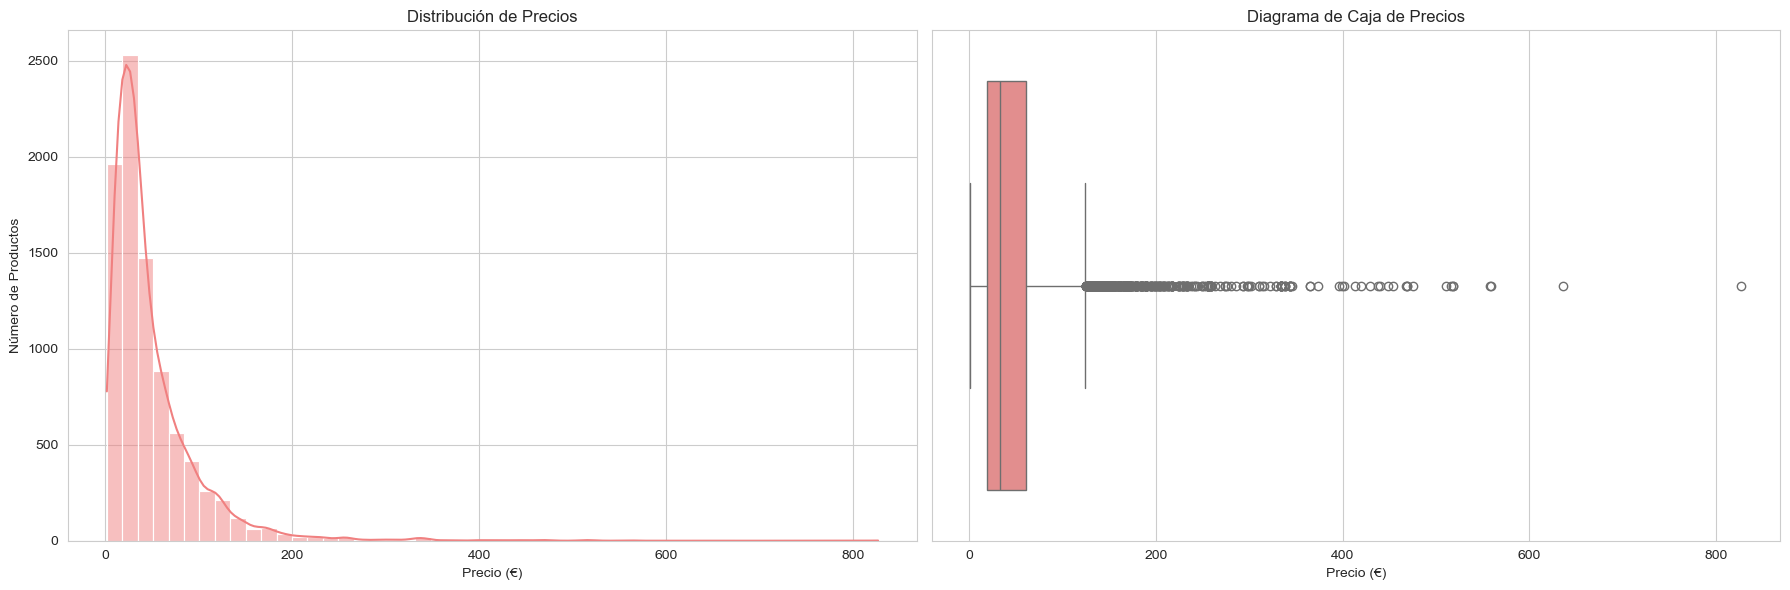


--- Top 10 Productos Más Caros ---
                                                 nombre  precio
5403                             FOREO FAQ 202 LED Mask  826.95
7120                   Clé De Peau Beauté La Crème 50ml  635.95
6259  FOREO BEAR 2 Firm and Lift Supercharged Set - ...  558.80
5805  NuFACE Trinity+ and Effective Lip and Eye Atta...  557.95
8442                    FaceGym LIGHTWEAR LED Face Mask  517.95
7804  SkinCeuticals Triple Lipid Restore 2:4:2 Anti-...  517.95
5402                             FOREO FAQ 201 LED Mask  516.45
8716  Imedeen Prime Renewal Beauty & Skin Supplement...  510.95
7119                   Clé De Peau Beauté La Crème 30ml  474.95
6260  FOREO BEAR 2 Body Sculpt and Tone Supercharged...  468.80


In [34]:
# Primero, veamos estadísticas descriptivas básicas para la columna 'precio'
print("--- Estadísticas Descriptivas del Precio ---")
# Usamos .dropna() para ignorar los productos sin precio (NULL)
print(df['precio'].dropna().describe())

# Visualización: Histograma y Boxplot para ver la distribución y outliers

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Histograma
sns.histplot(df['precio'].dropna(), bins=50, kde=True, ax=axes[0], color='lightcoral')
axes[0].set_title('Distribución de Precios')
axes[0].set_xlabel('Precio (€)')
axes[0].set_ylabel('Número de Productos')

# Boxplot (ideal para ver outliers)
sns.boxplot(x=df['precio'].dropna(), ax=axes[1], color='lightcoral')
axes[1].set_title('Diagrama de Caja de Precios')
axes[1].set_xlabel('Precio (€)')

plt.tight_layout()
plt.show()

# Opcional: Ver los productos más caros (posibles outliers o lujo)
print("\n--- Top 10 Productos Más Caros ---")
print(df.sort_values(by='precio', ascending=False)[['nombre', 'precio']].head(10))

## 9. Análisis de Palabras Clave en Descripciones (N-gramas)

Identificar los términos más frecuentes en las descripciones nos da una idea de los beneficios y características principales de nuestros productos. Usaremos N-gramas (secuencias de 1, 2 y 3 palabras) para encontrar las palabras y frases clave más comunes, después de limpiar el texto (stopwords, etc.).

In [39]:
import nltk
from nltk.corpus import stopwords
from collections import Counter
import re

# Descargar stopwords si no las tienes (solo la primera vez)
try:
    stopwords.words('spanish')
except LookupError:
    nltk.download('stopwords')

# Obtenemos la lista de stopwords en español
stop_words = set(stopwords.words('spanish'))

# Añadimos algunas palabras comunes irrelevantes específicas de cosmética/web
additional_stopwords = {'producto', 'uso', 'piel', 'puede', 'ser', 'si', 'mas', 'contenido', 'envase', 'the', 'and', 'with', 'for', 'your', 'that', 'while', 'this'}
stop_words.update(additional_stopwords)

def limpiar_texto(texto):
    """Función para limpiar texto: minúsculas, solo letras/espacios, sin stopwords."""
    if pd.isna(texto):
        return ""
    texto = texto.lower()
    texto = re.sub(r'[^a-záéíóúüñ\s]', '', texto) # Solo letras y espacios
    palabras = texto.split()
    palabras_limpias = [palabra for palabra in palabras if palabra not in stop_words and len(palabra) > 2]
    return " ".join(palabras_limpias)

# Aplicamos la limpieza a la columna 'descripcion'
print("Limpiando textos de descripción...")
df['descripcion_limpia'] = df['descripcion'].apply(limpiar_texto)
print("Textos limpiados.")

# Concatenamos todas las descripciones limpias en un solo gran texto
corpus = " ".join(df['descripcion_limpia'])

Limpiando textos de descripción...
Textos limpiados.



--- Top 25 Palabras Clave (Unigramas) ---
[('skin', 4273), ('cabello', 4262), ('fórmula', 3980), ('hair', 2966), ('suave', 2554), ('aspecto', 2492), ('formula', 2445), ('set', 2206), ('hidratación', 2127), ('ayuda', 1988), ('natural', 1941), ('crema', 1934), ('color', 1712), ('acabado', 1643), ('fragancia', 1632), ('aceite', 1593), ('brillo', 1504), ('oil', 1391), ('look', 1376), ('proporciona', 1360), ('hidratante', 1332), ('mezcla', 1324), ('maquillaje', 1298), ('mientras', 1266), ('base', 1247)]

--- Top 25 Frases Clave (Bigramas) ---
[('set contents', 1034), ('ácido hialurónico', 731), ('eau parfum', 724), ('cuero cabelludo', 610), ('hyaluronic acid', 566), ('crema hidratante', 458), ('líneas expresión', 429), ('larga duración', 371), ('set contiene', 364), ('tipo pieles', 347), ('notas salida', 336), ('fine lines', 320), ('skin types', 287), ('eau toilette', 285), ('base maquillaje', 279), ('fórmula ligera', 277), ('testado animales', 268), ('pieles sensibles', 249), ('contorno o

/tmp/ipykernel_43768/3915417990.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Frecuencia', y='Bigrama', data=bigramas_df, palette='viridis')


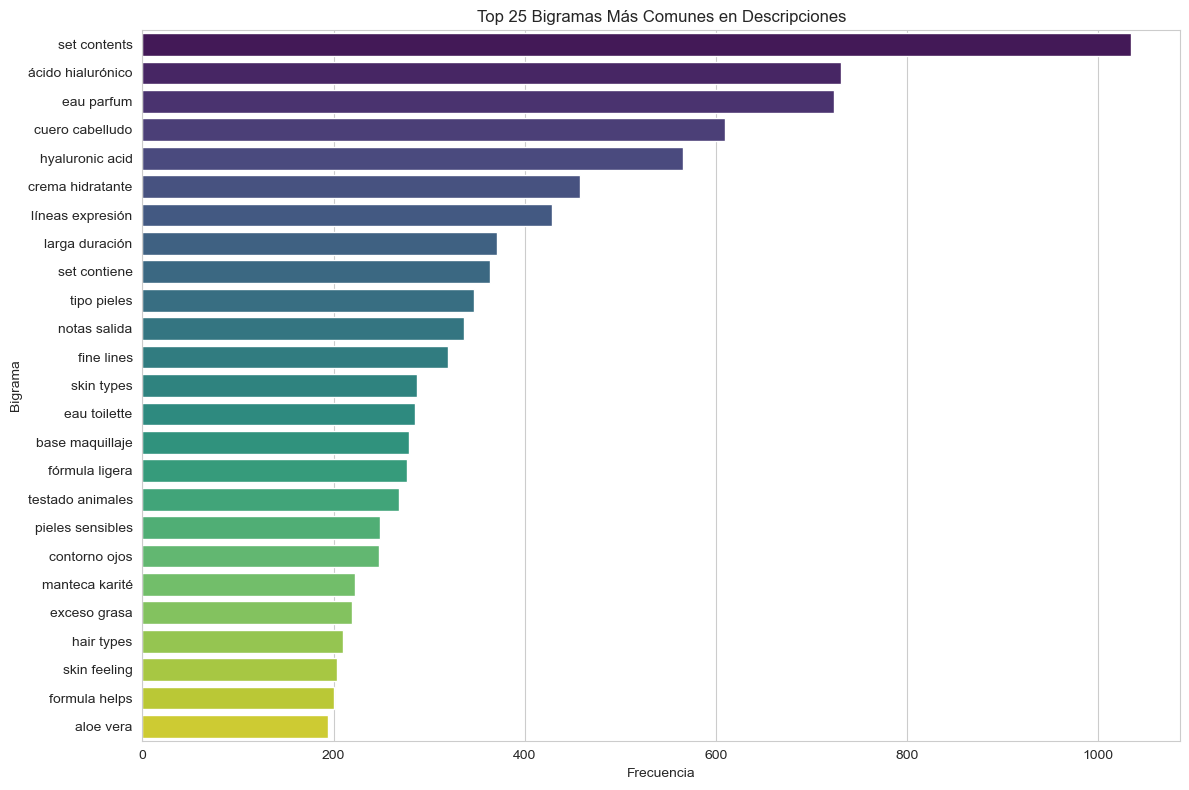

In [40]:
from nltk import ngrams

# Función para obtener los N-gramas más comunes
def get_top_ngrams(corpus, n, top_k=20):
    palabras = corpus.split()
    n_grams = ngrams(palabras, n)
    ngram_counts = Counter(n_grams)
    return ngram_counts.most_common(top_k)

# --- Análisis de Unigramas (Palabras sueltas) ---
top_unigramas = get_top_ngrams(corpus, 1, 25)
print("\n--- Top 25 Palabras Clave (Unigramas) ---")
# Convertimos tuplas a strings para mejor legibilidad
print([(' '.join(gram), count) for gram, count in top_unigramas])

# --- Análisis de Bigramas (Pares de palabras) ---
top_bigramas = get_top_ngrams(corpus, 2, 25)
print("\n--- Top 25 Frases Clave (Bigramas) ---")
print([(' '.join(gram), count) for gram, count in top_bigramas])

# --- Análisis de Trigramas (Tríos de palabras) ---
top_trigramas = get_top_ngrams(corpus, 3, 25)
print("\n--- Top 25 Frases Clave (Trigramas) ---")
print([(' '.join(gram), count) for gram, count in top_trigramas])

# Visualización de los Bigramas más comunes
if top_bigramas:
    bigramas_df = pd.DataFrame(top_bigramas, columns=['Bigrama', 'Frecuencia'])
    # Convertir tupla a string para el gráfico
    bigramas_df['Bigrama'] = bigramas_df['Bigrama'].apply(lambda x: ' '.join(x)) 
    
    plt.figure(figsize=(12, 8))
    sns.barplot(x='Frecuencia', y='Bigrama', data=bigramas_df, palette='viridis')
    plt.title('Top 25 Bigramas Más Comunes en Descripciones')
    plt.xlabel('Frecuencia')
    plt.ylabel('Bigrama')
    plt.tight_layout()
    plt.show()

## 10. Estandarización de Nombres de Producto

Los nombres de los productos contienen información extra (como el tamaño en ml entre paréntesis) y símbolos especiales (`®`, `™`, `Â `, etc.) que pueden dificultar el análisis o agrupamiento por nombre.

Vamos a crear una nueva columna `nombre_estandarizado` con una versión limpia de los nombres.

In [45]:
import re
import pandas as pd # Asegúrate de importar pandas

def estandarizar_nombre(nombre):
    """Limpia y estandariza el nombre de un producto."""
    if pd.isna(nombre):
        return None
        
    nombre_limpio = nombre # Empezamos con el original
    
    # 1. Eliminar contenido entre paréntesis
    nombre_limpio = re.sub(r'\(.*?\)', '', nombre_limpio)
    
    # 2. Eliminar "- [cantidad]ml" al final
    nombre_limpio = re.sub(r'\s*-\s*\d+ml$', '', nombre_limpio, flags=re.IGNORECASE)
    
    # 3. Eliminar "[espacio][cantidad]ml" al final
    nombre_limpio = re.sub(r'\s+\d+ml$', '', nombre_limpio, flags=re.IGNORECASE)
    
    # --- NUEVAS REGLAS ---
    # 4. Eliminar "[espacio][cantidad]g" al final
    #    Regex: \s+\d+g$ -> Busca uno o más espacios, seguido de números y 'g' al final
    nombre_limpio = re.sub(r'\s+\d+g$', '', nombre_limpio, flags=re.IGNORECASE)
    
    # 5. Eliminar "[espacio][cantidad] L" al final (por si acaso)
    #    Regex: \s+\d+\s*L$ -> Busca uno o más espacios, números, opcionalmente espacio, y 'L' al final
    nombre_limpio = re.sub(r'\s+\d+\s*L$', '', nombre_limpio, flags=re.IGNORECASE)
    
    # 6. Eliminar símbolos y caracteres extraños
    simbolos_a_quitar = ['®', '™', 'Â', ' '] 
    for simbolo in simbolos_a_quitar:
        nombre_limpio = nombre_limpio.replace(simbolo, '')
        
    # 7. Limpiar espacios extra
    nombre_limpio = ' '.join(nombre_limpio.split())
    
    # Devolver None si el nombre quedó vacío después de limpiar
    return nombre_limpio if nombre_limpio else None

# --- CÓDIGO PARA LA CELDA DEL NOTEBOOK ---

# Hacemos una copia para comparar al final
nombres_originales = df['nombre'].copy()

# Aplicamos la función para SOBRESCRIBIR la columna 'nombre'
print("Estandarizando y sobrescribiendo la columna 'nombre' (versión final)...")
df['nombre'] = df['nombre'].apply(estandarizar_nombre)
print("Columna 'nombre' estandarizada.")

# Mostramos una comparación para ver el resultado
print("\n--- Comparación de Nombres (Original vs. Estandarizado Final) ---")
df_comparacion = pd.DataFrame({'nombre_original': nombres_originales, 'nombre_limpio': df['nombre']})
# Mostramos más ejemplos para verificar las nuevas reglas
print(df_comparacion.sample(15)) # Muestra aleatoria de 15

# Opcional: Ver cuántos nombres únicos hay antes y después
print(f"\nNombres únicos originales: {nombres_originales.nunique()}")
print(f"Nombres únicos estandarizados (en 'nombre'): {df['nombre'].nunique()}")

Estandarizando y sobrescribiendo la columna 'nombre' (versión final)...
Columna 'nombre' estandarizada.

--- Comparación de Nombres (Original vs. Estandarizado Final) ---
                                        nombre_original  \
3766     Makeup Revolution Superdewy Tinted Moisturiser   
4926  Sérum con un 10% de ácido azelaico Super Solut...   
4143       First Aid Beauty Ingrown Hair Treatment Pads   
2040      ESPA Tri-Active Resilience ProBiome Eye Cream   
2163                    Medik8 Daily Radiance Vitamin C   
7084                        Gallinée Face Recovery Mask   
5918       Anastasia Beverly Hills Brow Freeze - Deluxe   
6546  Myvitamins Magnesium Gummies, Raspberry Flavou...   
6968  NIOXIN Scalp and Hair Thickening System 4 Cond...   
4488  Matrix Total Results InstaCure Anti-Breakage S...   
7403                     DIRTEA Matcha Super Blend 180g   
5448  Sérum capilar nutritivo de noche Essence Absol...   
2402  FOREO Coconut Oil UFO/UFO Mini Nourishing Face...   
723

In [46]:
import sqlite3
import pandas as pd # Asegúrate de que pandas esté importado

print("Iniciando el guardado en la base de datos...")

# 1. Definimos las columnas que queremos guardar
#    (Ya no necesitamos 'nombre_estandarizado')
columnas_finales = [
    'nombre',          # <-- Esta columna ahora contiene los nombres limpios
    'descripcion', 
    'ingredientes', 
    'precio', 
    'embedding_vector'
]

# 2. Creamos un DataFrame final solo con esas columnas
df_final = df[columnas_finales]

# 3. Definimos los tipos de datos de SQL
sql_dtypes = {
    'nombre': 'TEXT', 
    'descripcion': 'TEXT', 
    'ingredientes': 'TEXT', 
    'precio': 'REAL', 
    'embedding_vector': 'TEXT'
}

try:
    # 4. Conectamos a la base de datos
    conn = sqlite3.connect(DB_NAME)
    
    # 5. Sobrescribimos la tabla 'productos_scraped' con el DataFrame limpio
    df_final.to_sql(
        'productos_scraped', 
        conn, 
        if_exists='replace',  # 'replace' borra la tabla antigua y crea una nueva
        index=False,          # No guardar el índice de Pandas
        dtype=sql_dtypes      # Asegurar tipos correctos
    )
    
    conn.close()
    
    print("\n🎉 ¡ÉXITO! La base de datos 'db_cosmetica.db' ha sido actualizada.")
    print("   La columna 'nombre' ahora contiene los nombres estandarizados.")
    print(f"Total de productos guardados: {len(df_final)}")
    print(f"Total de ingredientes nulos (limpios): {df_final['ingredientes'].isnull().sum()}")

except Exception as e:
    print(f"\n❌ ERROR al guardar en la base de datos: {e}")
    if 'conn' in locals() and conn:
        conn.close()

Iniciando el guardado en la base de datos...

🎉 ¡ÉXITO! La base de datos 'db_cosmetica.db' ha sido actualizada.
   La columna 'nombre' ahora contiene los nombres estandarizados.
Total de productos guardados: 8719
Total de ingredientes nulos (limpios): 1422
